# Лабораторная работа №1
## «Анализ и прогнозирование временных рядов на примере розничных продаж»

**Цель:** Провести анализ временного ряда розничных продаж, выполнить декомпозицию, построить модели ARIMA и SARIMAX.

**Данные:** `retail_sales_mock_data.csv` — месячные продажи за 2020-2023 гг.

## Импорт библиотек

In [57]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.fft import fft, fftfreq
import pywt

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

## Загрузка данных

In [58]:
df = pd.read_csv('retail_sales_mock_data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.index.freq = 'MS'

print(f"Размер: {df.shape}")
print(f"Период: {df.index.min()} — {df.index.max()}")
df.info()
df.head(10)

Размер: (48, 3)
Период: 2020-01-01 00:00:00 — 2023-12-01 00:00:00
<class 'pandas.DataFrame'>
DatetimeIndex: 48 entries, 2020-01-01 to 2023-12-01
Freq: MS
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalesAmount   48 non-null     int64
 1   Promotion     48 non-null     int64
 2   HolidayMonth  48 non-null     int64
dtypes: int64(3)
memory usage: 1.5 KB


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0
2020-06-01,9131,1,0
2020-07-01,9089,0,0
2020-08-01,10300,0,0
2020-09-01,10464,0,0


---
# 2.1. Разведочный анализ данных (EDA)

### Описательная статистика

In [59]:
sales = df['SalesAmount']

stats_df = pd.DataFrame({
    'Показатель': ['Количество', 'Среднее', 'Ст. откл.', 'Мин', 'Q1', 'Медиана', 'Q3', 'Макс', 'Размах', 'CV (%)', 'Асимметрия', 'Эксцесс'],
    'Значение': [len(sales), round(sales.mean(), 2), round(sales.std(), 2), sales.min(), sales.quantile(0.25), 
                 sales.median(), sales.quantile(0.75), sales.max(), sales.max() - sales.min(), 
                 round(sales.std() / sales.mean() * 100, 2), round(sales.skew(), 3), round(sales.kurtosis(), 3)]
})
print(stats_df.to_string(index=False))

print(f"\nПропуски: {sales.isna().sum()}")
Q1, Q3 = sales.quantile(0.25), sales.quantile(0.75)
IQR = Q3 - Q1
outliers = sales[(sales < Q1 - 1.5*IQR) | (sales > Q3 + 1.5*IQR)]
print(f"Выбросы (IQR): {len(outliers)}")

Показатель  Значение
Количество    48.000
   Среднее 11768.540
 Ст. откл.  2257.540
       Мин  7783.000
        Q1 10219.750
   Медиана 11851.000
        Q3 13014.000
      Макс 17996.000
    Размах 10213.000
    CV (%)    19.180
Асимметрия     0.391
   Эксцесс     0.165

Пропуски: 0
Выбросы (IQR): 1


### Визуализация временного ряда

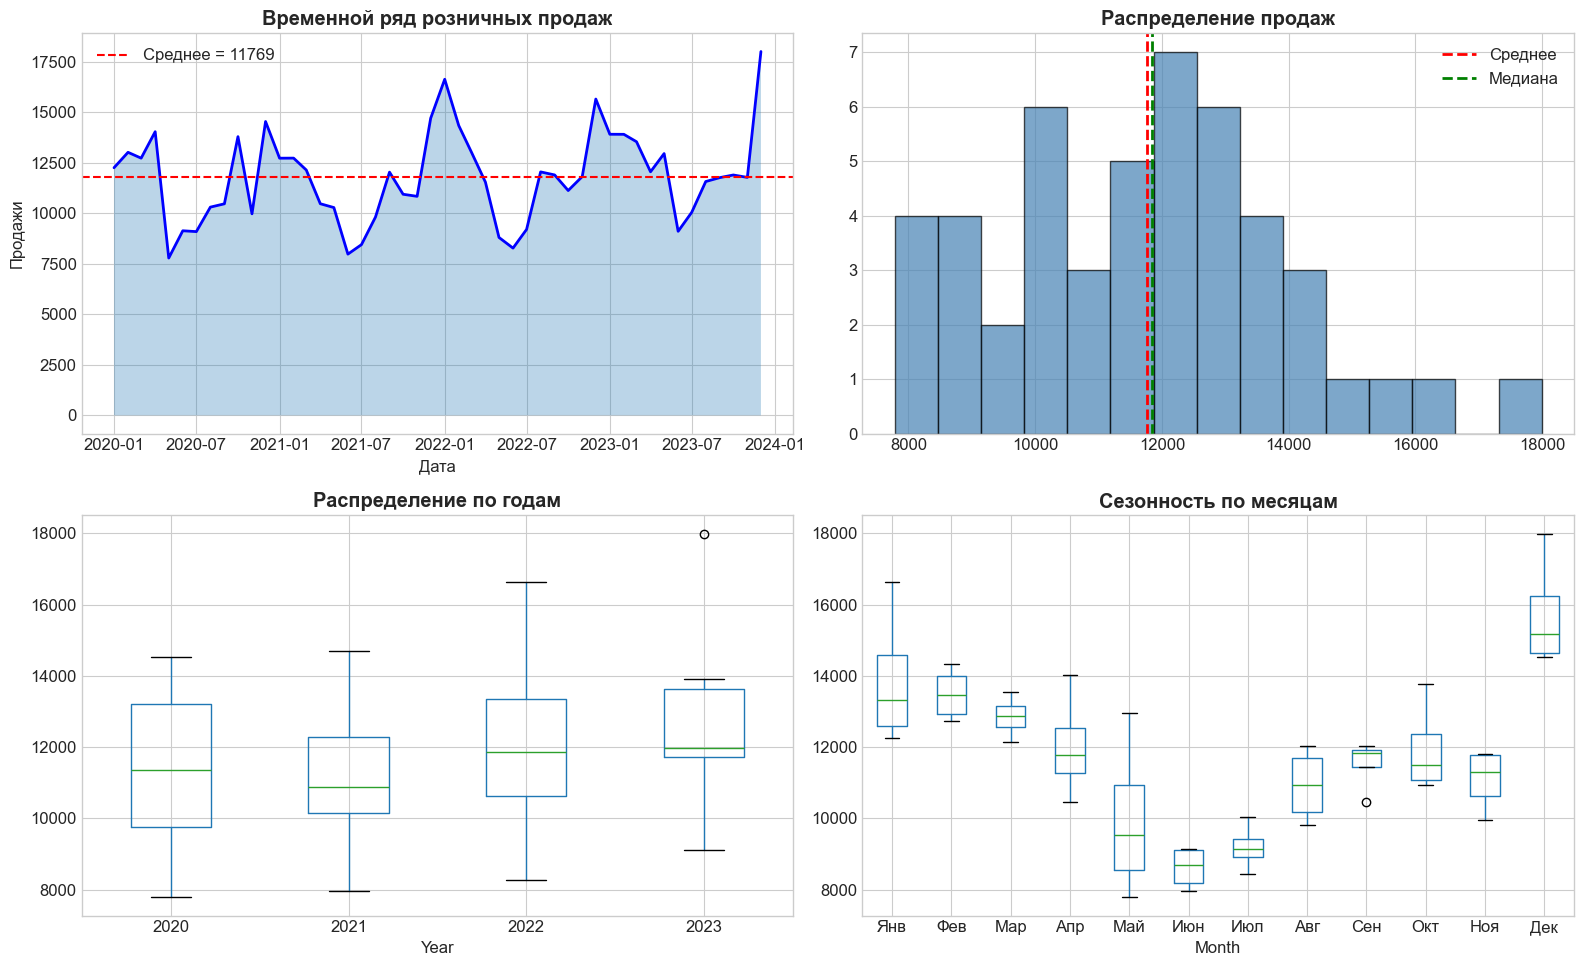

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(sales.index, sales.values, 'b-', linewidth=2)
axes[0, 0].axhline(y=sales.mean(), color='r', linestyle='--', label=f'Среднее = {sales.mean():.0f}')
axes[0, 0].fill_between(sales.index, sales.values, alpha=0.3)
axes[0, 0].set_title('Временной ряд розничных продаж', fontweight='bold')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Продажи')
axes[0, 0].legend()

axes[0, 1].hist(sales.values, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].axvline(sales.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее')
axes[0, 1].axvline(sales.median(), color='green', linestyle='--', linewidth=2, label=f'Медиана')
axes[0, 1].set_title('Распределение продаж', fontweight='bold')
axes[0, 1].legend()

df_yearly = df.copy()
df_yearly['Year'] = df_yearly.index.year
df_yearly.boxplot(column='SalesAmount', by='Year', ax=axes[1, 0])
axes[1, 0].set_title('Распределение по годам', fontweight='bold')
plt.suptitle('')

df_monthly = df.copy()
df_monthly['Month'] = df_monthly.index.month
month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
df_monthly.boxplot(column='SalesAmount', by='Month', ax=axes[1, 1])
axes[1, 1].set_xticklabels(month_names)
axes[1, 1].set_title('Сезонность по месяцам', fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

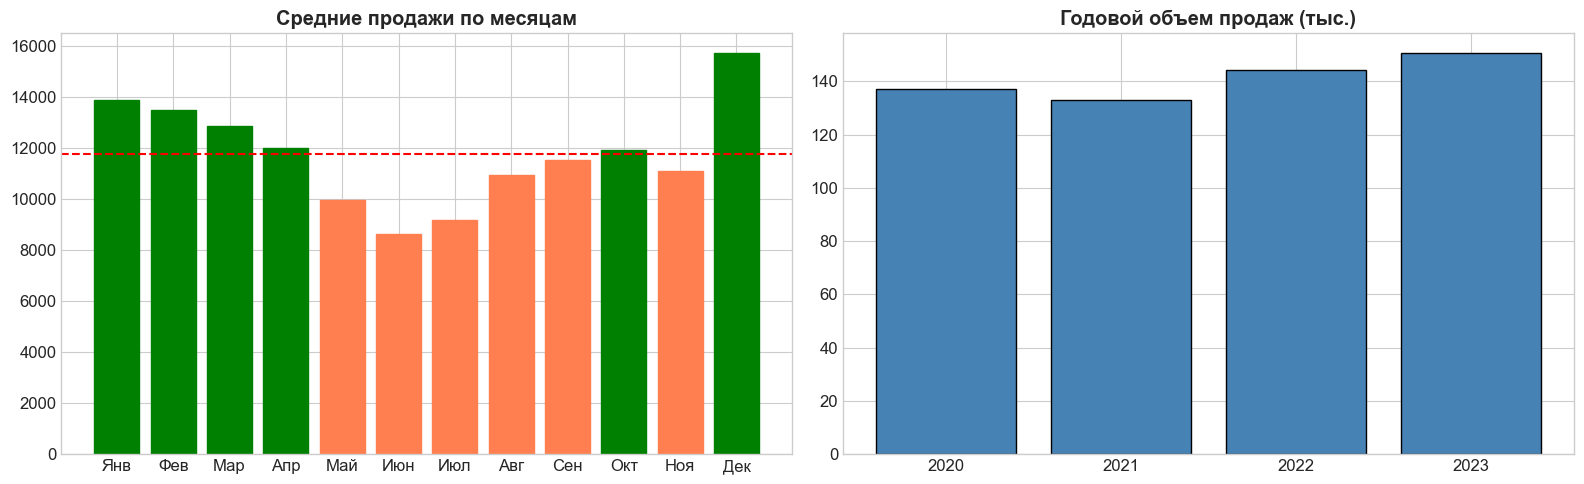

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

monthly_avg = df.groupby(df.index.month)['SalesAmount'].mean()
bars = axes[0].bar(range(1, 13), monthly_avg.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].axhline(y=sales.mean(), color='red', linestyle='--')
axes[0].set_title('Средние продажи по месяцам', fontweight='bold')
for bar, val in zip(bars, monthly_avg.values):
    bar.set_color('green' if val > sales.mean() else 'coral')

yearly_stats = df.groupby(df.index.year)['SalesAmount'].sum()
axes[1].bar(range(len(yearly_stats)), yearly_stats/1000, color='steelblue', edgecolor='black')
axes[1].set_xticks(range(len(yearly_stats)))
axes[1].set_xticklabels(yearly_stats.index)
axes[1].set_title('Годовой объем продаж (тыс.)', fontweight='bold')

plt.tight_layout()
plt.show()

### Анализ стационарности

In [62]:
def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\nТест Дики-Фуллера {title}")
    print(f"Статистика: {result[0]:.4f}, p-value: {result[1]:.6f}")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")
    print(f"Вывод: {'Стационарен' if result[1] < 0.05 else 'Нестационарен'}")
    return result[1] < 0.05

def kpss_test(series, title=''):
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"\nKPSS тест {title}")
    print(f"Статистика: {result[0]:.4f}, p-value: {result[1]:.4f}")
    print(f"Вывод: {'Стационарен' if result[1] >= 0.05 else 'Нестационарен'}")
    return result[1] >= 0.05

adf_test(sales, "(исходный ряд)")
kpss_test(sales, "(исходный ряд)")


Тест Дики-Фуллера (исходный ряд)
Статистика: -4.5142, p-value: 0.000185
  1%: -3.5966
  5%: -2.9333
  10%: -2.6050
Вывод: Стационарен

KPSS тест (исходный ряд)
Статистика: 0.1388, p-value: 0.1000
Вывод: Стационарен


np.True_

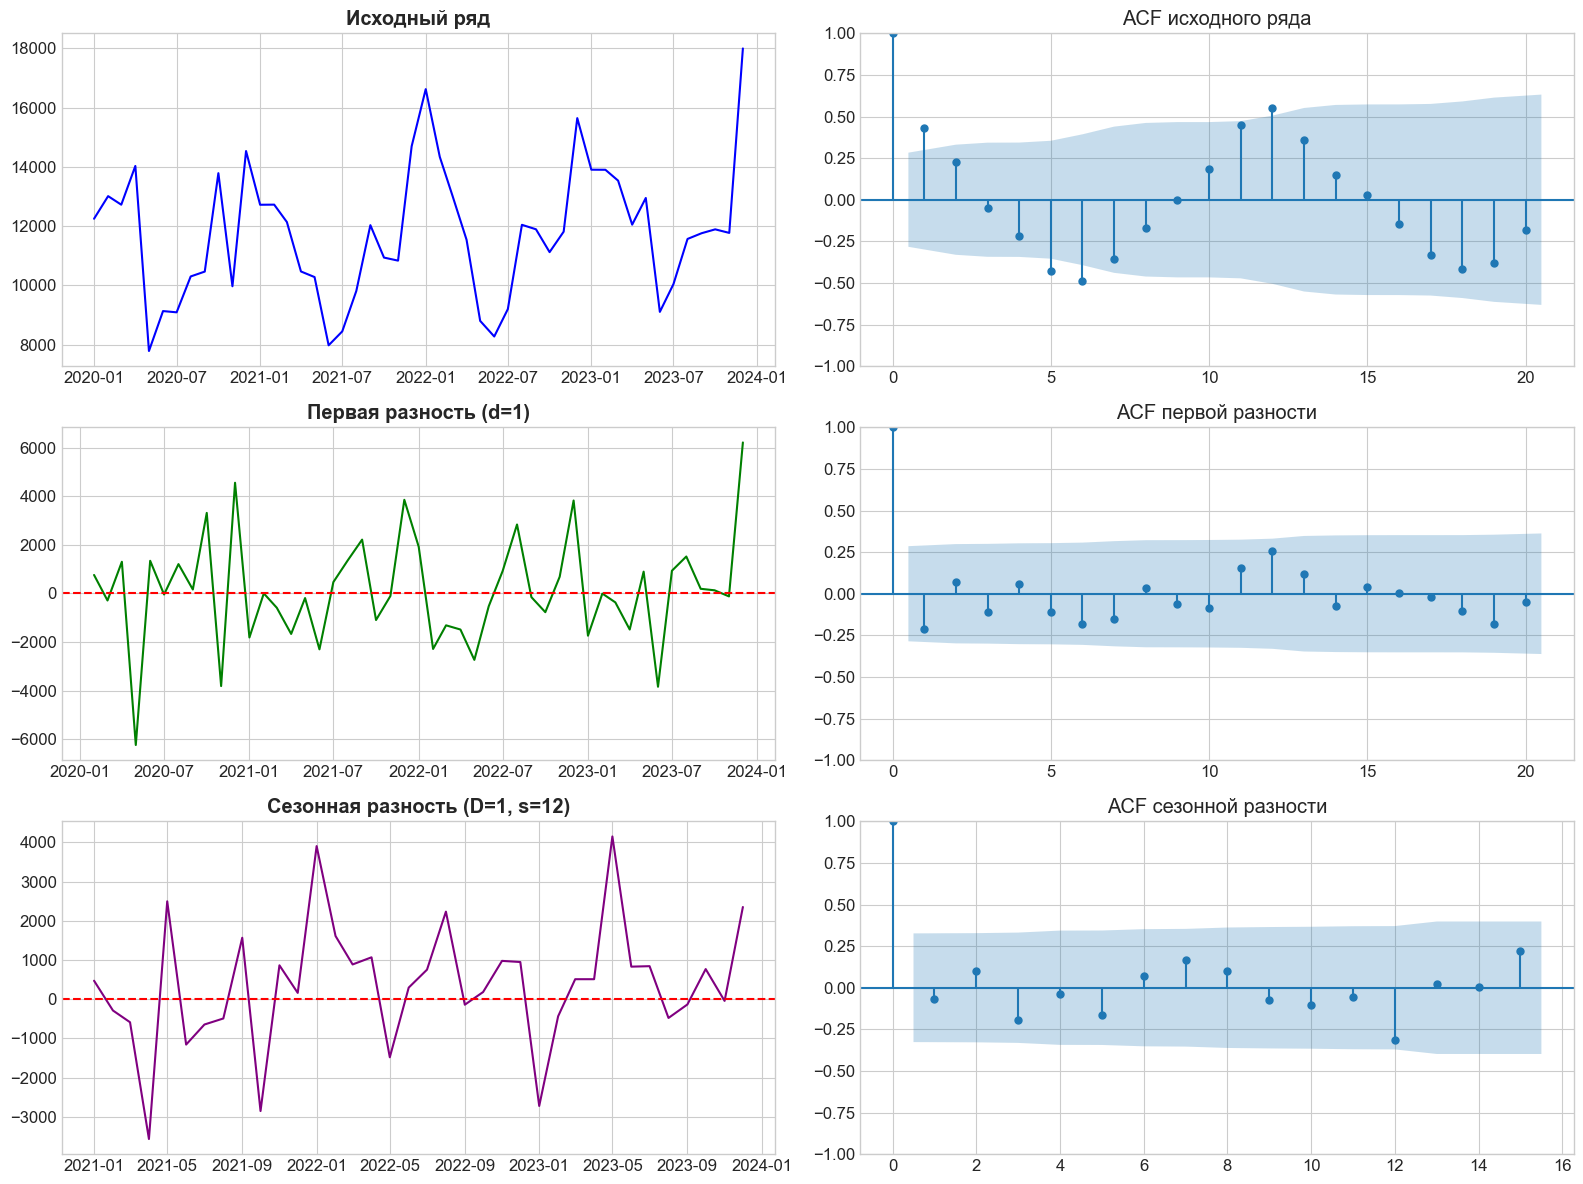


Тест Дики-Фуллера (первая разность)
Статистика: -5.6296, p-value: 0.000001
  1%: -3.6267
  5%: -2.9460
  10%: -2.6117
Вывод: Стационарен

Тест Дики-Фуллера (сезонная разность)
Статистика: -3.6261, p-value: 0.005281
  1%: -3.6535
  5%: -2.9572
  10%: -2.6176
Вывод: Стационарен


np.True_

In [63]:
sales_diff1 = sales.diff().dropna()
sales_diff_seasonal = sales.diff(12).dropna()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

axes[0, 0].plot(sales.index, sales.values, 'b-', linewidth=1.5)
axes[0, 0].set_title('Исходный ряд', fontweight='bold')
plot_acf(sales, ax=axes[0, 1], lags=20, title='ACF исходного ряда')

axes[1, 0].plot(sales_diff1.index, sales_diff1.values, 'g-', linewidth=1.5)
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_title('Первая разность (d=1)', fontweight='bold')
plot_acf(sales_diff1, ax=axes[1, 1], lags=20, title='ACF первой разности')

axes[2, 0].plot(sales_diff_seasonal.index, sales_diff_seasonal.values, 'purple', linewidth=1.5)
axes[2, 0].axhline(y=0, color='red', linestyle='--')
axes[2, 0].set_title('Сезонная разность (D=1, s=12)', fontweight='bold')
plot_acf(sales_diff_seasonal, ax=axes[2, 1], lags=15, title='ACF сезонной разности')

plt.tight_layout()
plt.show()

adf_test(sales_diff1, "(первая разность)")
adf_test(sales_diff_seasonal, "(сезонная разность)")

### ACF и PACF

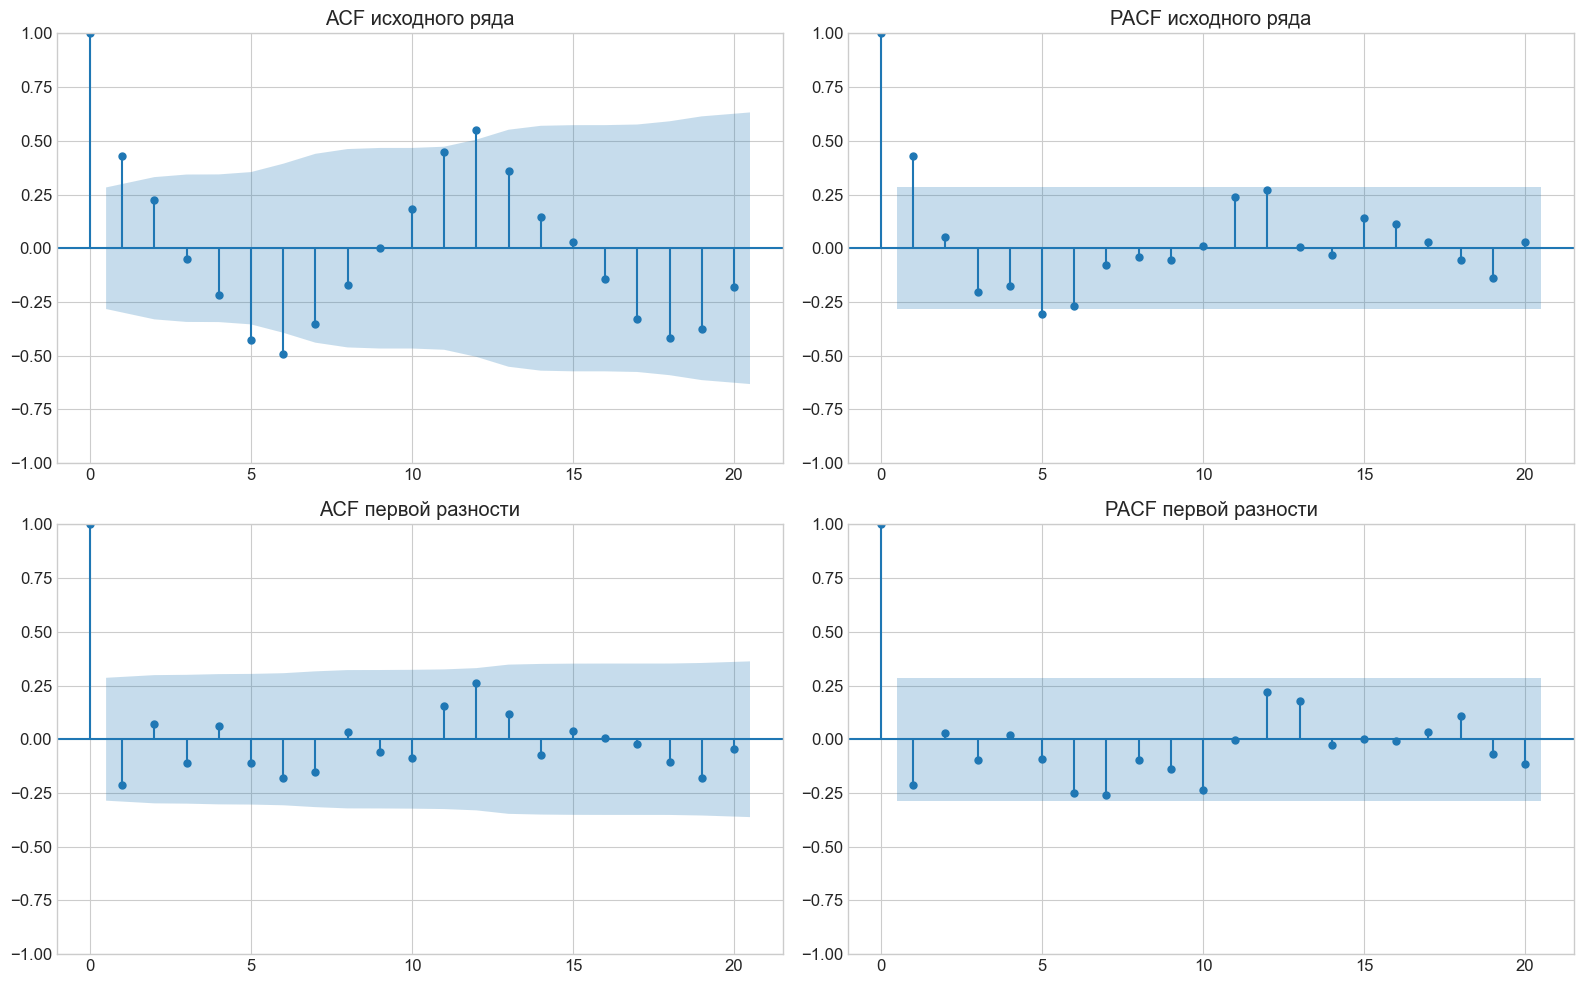


Интерпретация ACF/PACF:
- Медленное затухание ACF → нестационарность, нужно дифференцирование
- Значимые лаги на 12 → сезонность с периодом 12 месяцев
- По графикам: d=1, D=1, p=1-2, q=1-2, P=1, Q=1, s=12



In [64]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

max_lags_original = min(20, len(sales) // 2 - 1)
max_lags_diff = min(20, len(sales_diff1) // 2 - 1)

plot_acf(sales, ax=axes[0, 0], lags=max_lags_original, title='ACF исходного ряда')
plot_pacf(sales, ax=axes[0, 1], lags=max_lags_original, title='PACF исходного ряда', method='ywm')
plot_acf(sales_diff1, ax=axes[1, 0], lags=max_lags_diff, title='ACF первой разности')
plot_pacf(sales_diff1, ax=axes[1, 1], lags=max_lags_diff, title='PACF первой разности', method='ywm')

plt.tight_layout()
plt.show()

print("""
Интерпретация ACF/PACF:
- Медленное затухание ACF → нестационарность, нужно дифференцирование
- Значимые лаги на 12 → сезонность с периодом 12 месяцев
- По графикам: d=1, D=1, p=1-2, q=1-2, P=1, Q=1, s=12
""")

---
## Декомпозиция временного ряда

### Метод 1: Классическая декомпозиция

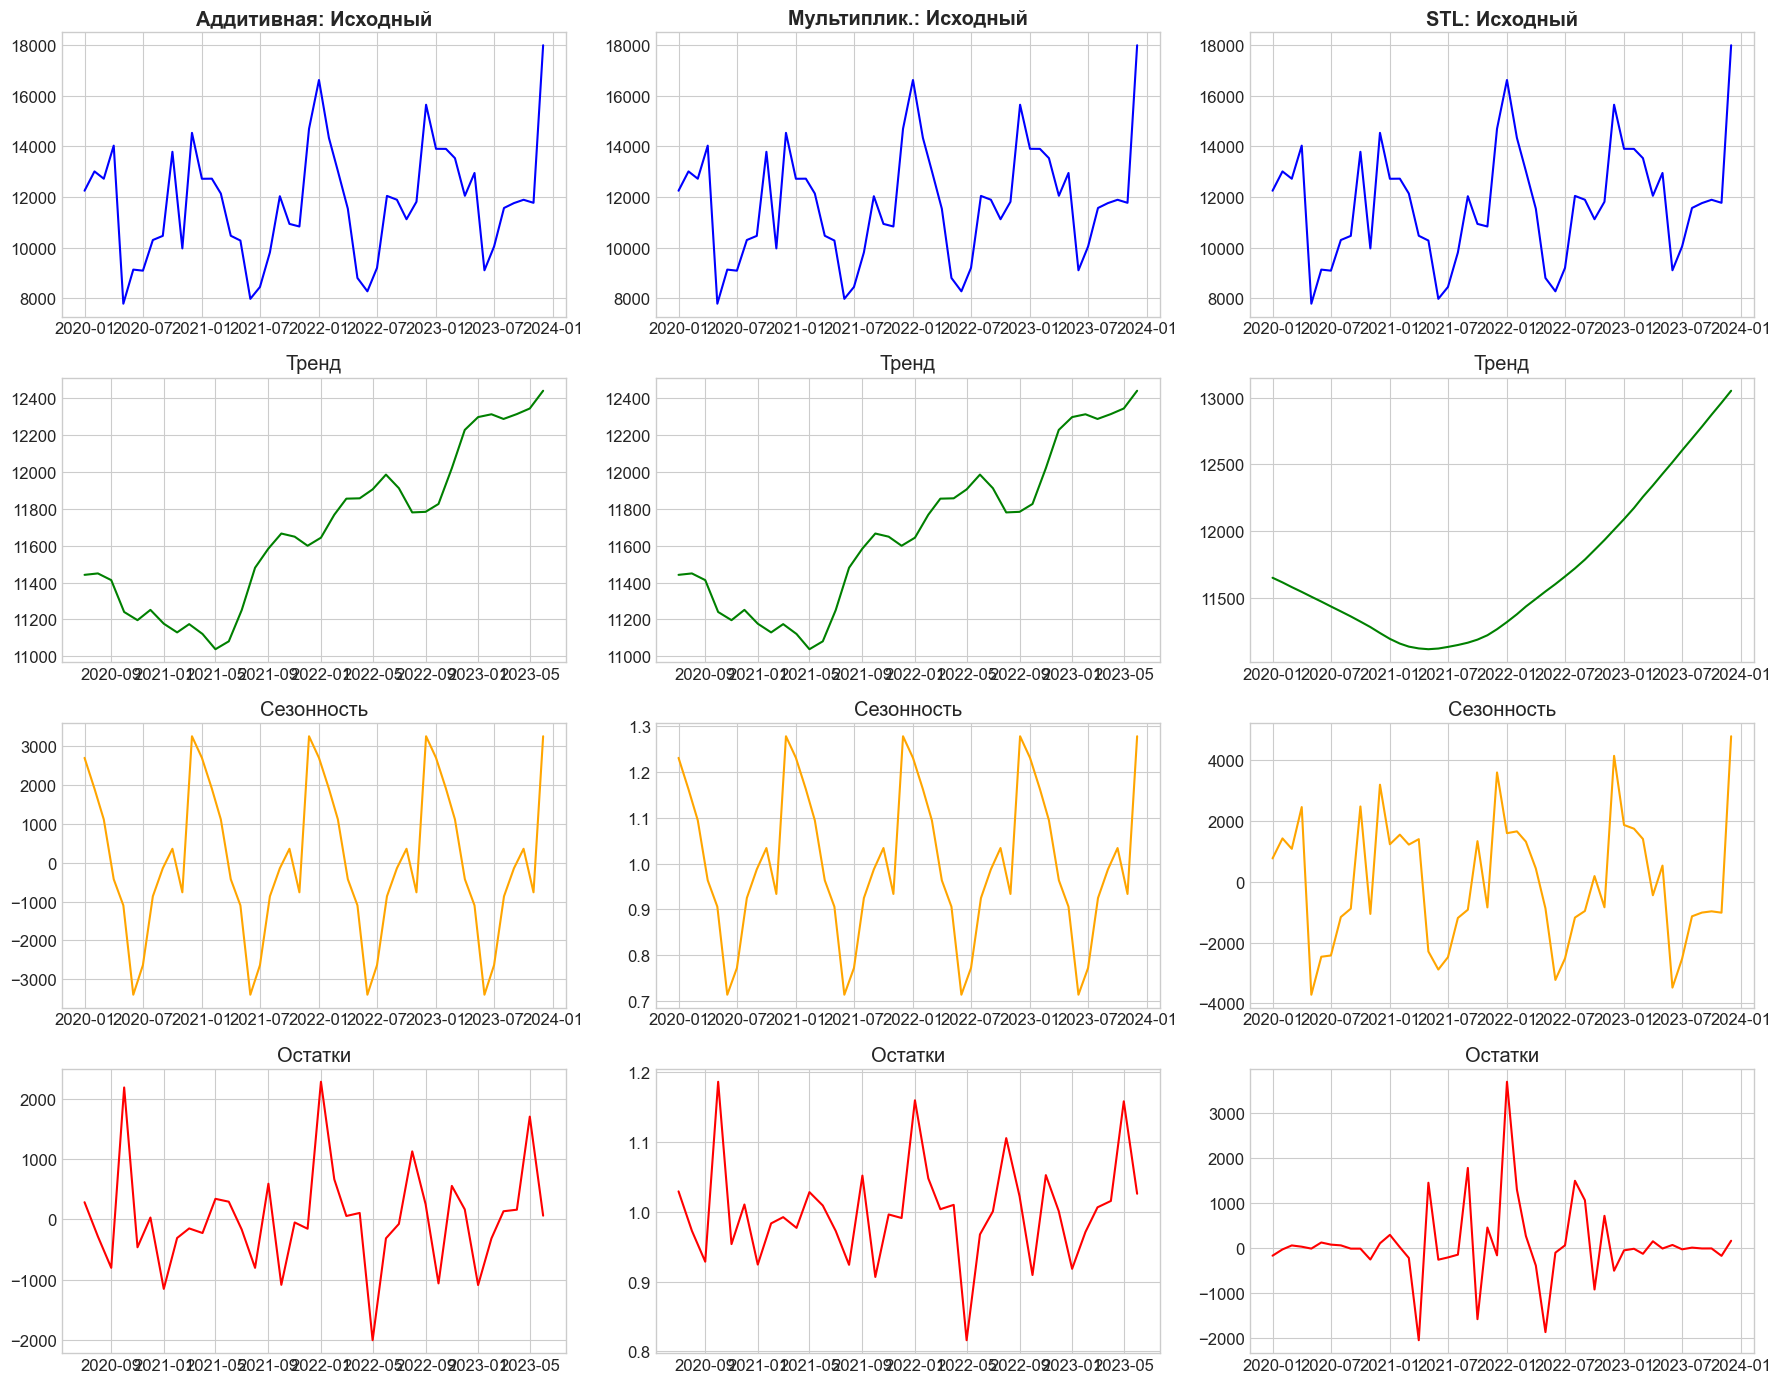

Дисперсия остатков:
  Аддитивная: 738,286
  Мультипликативная: 0.0052
  STL: 762,876


In [65]:
decomp_add = seasonal_decompose(sales, model='additive', period=12)
decomp_mult = seasonal_decompose(sales, model='multiplicative', period=12)
stl = STL(sales, period=12, robust=True)
decomp_stl = stl.fit()

fig, axes = plt.subplots(4, 3, figsize=(18, 14))

for i, (decomp, name) in enumerate([(decomp_add, 'Аддитивная'), (decomp_mult, 'Мультиплик.'), (decomp_stl, 'STL')]):
    axes[0, i].plot(sales.index, decomp.observed, 'b-')
    axes[0, i].set_title(f'{name}: Исходный', fontweight='bold')
    axes[1, i].plot(sales.index, decomp.trend, 'g-')
    axes[1, i].set_title('Тренд')
    axes[2, i].plot(sales.index, decomp.seasonal, 'orange')
    axes[2, i].set_title('Сезонность')
    axes[3, i].plot(sales.index, decomp.resid, 'r-')
    axes[3, i].set_title('Остатки')

plt.tight_layout()
plt.show()

print(f"Дисперсия остатков:")
print(f"  Аддитивная: {np.nanvar(decomp_add.resid):,.0f}")
print(f"  Мультипликативная: {np.nanvar(decomp_mult.resid):,.4f}")
print(f"  STL: {np.nanvar(decomp_stl.resid):,.0f}")

### Метод 2: FFT (преобразование Фурье)

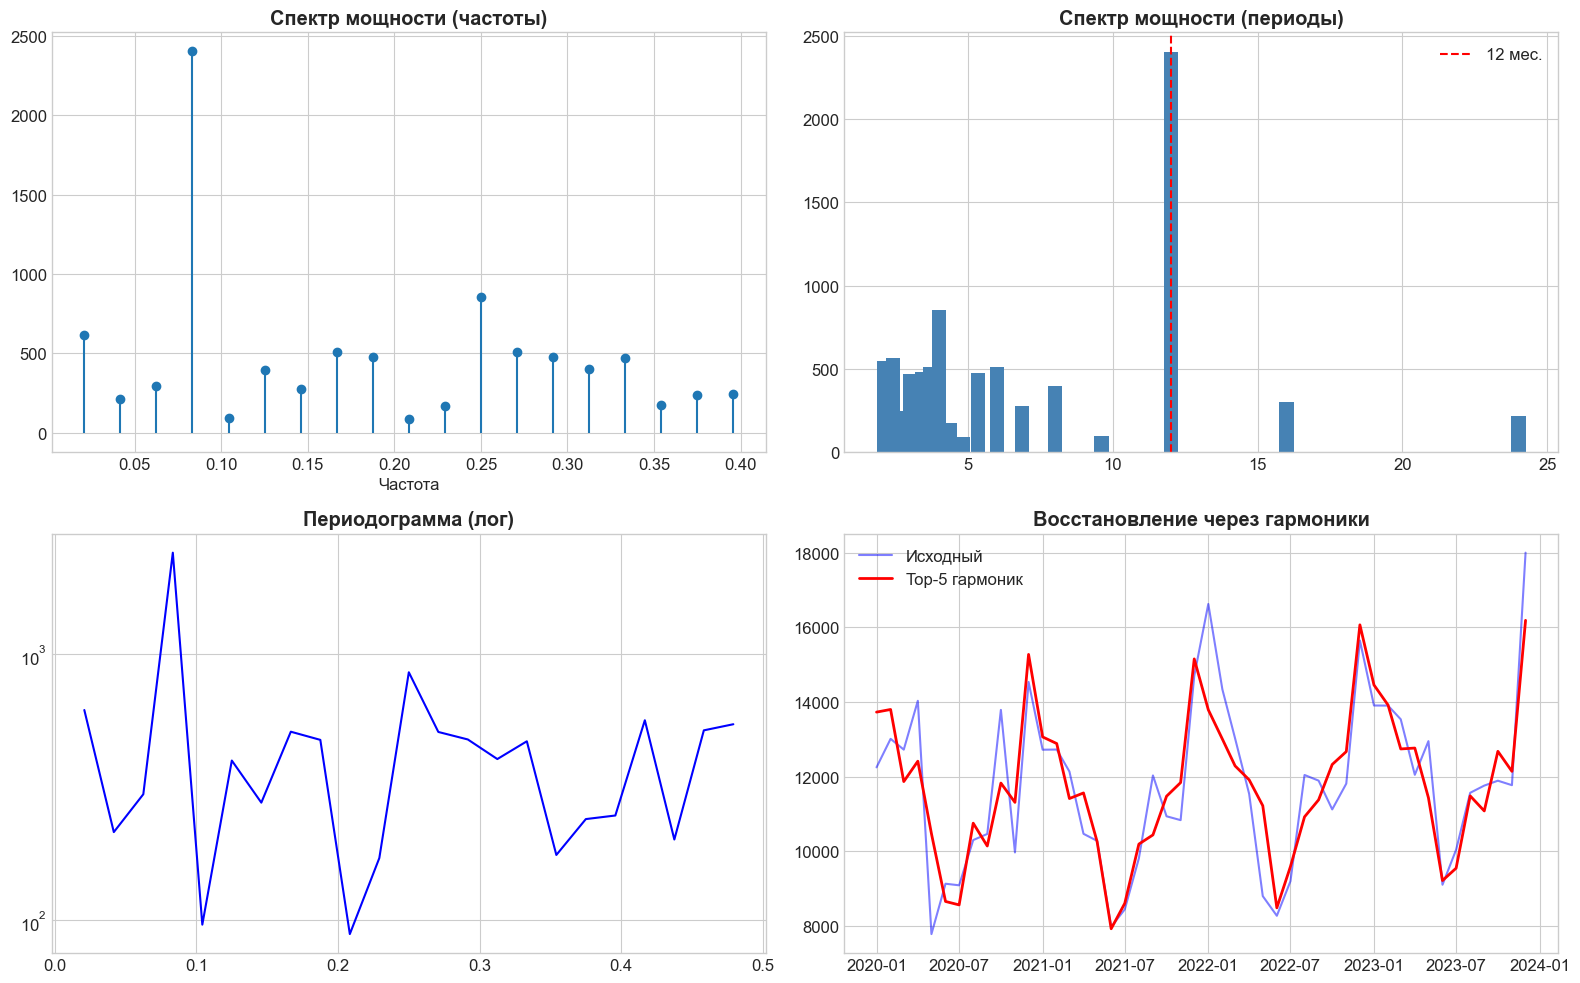

Доминирующие периоды:
  1. 12.0 мес., амплитуда: 2403.3
  2. 4.0 мес., амплитуда: 854.3
  3. 48.0 мес., амплитуда: 616.4
  4. 2.4 мес., амплитуда: 564.2
  5. 2.1 мес., амплитуда: 545.1


In [66]:
y = sales.values - sales.mean()
n = len(y)

yf = fft(y)
xf = fftfreq(n, d=1)[:n//2]
power = 2.0/n * np.abs(yf[0:n//2])
periods = 1 / xf[1:]
power_periods = power[1:]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].stem(xf[1:20], power[1:20], basefmt=' ')
axes[0, 0].set_title('Спектр мощности (частоты)', fontweight='bold')
axes[0, 0].set_xlabel('Частота')

mask = periods <= 24
axes[0, 1].bar(periods[mask], power_periods[mask], width=0.5, color='steelblue')
axes[0, 1].axvline(x=12, color='red', linestyle='--', label='12 мес.')
axes[0, 1].set_title('Спектр мощности (периоды)', fontweight='bold')
axes[0, 1].legend()

axes[1, 0].semilogy(xf[1:], power[1:], 'b-')
axes[1, 0].set_title('Периодограмма (лог)', fontweight='bold')

top_k = 5
indices = np.argsort(np.abs(yf))[-top_k*2:]
yf_filtered = np.zeros_like(yf)
yf_filtered[indices] = yf[indices]
y_filtered = np.real(np.fft.ifft(yf_filtered)) + sales.mean()

axes[1, 1].plot(sales.index, sales.values, 'b-', alpha=0.5, label='Исходный')
axes[1, 1].plot(sales.index, y_filtered, 'r-', linewidth=2, label=f'Top-{top_k} гармоник')
axes[1, 1].set_title('Восстановление через гармоники', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

top_indices = np.argsort(power_periods)[-5:][::-1]
print("Доминирующие периоды:")
for i, idx in enumerate(top_indices, 1):
    print(f"  {i}. {periods[idx]:.1f} мес., амплитуда: {power_periods[idx]:.1f}")

### Метод 3: Вейвлет-анализ

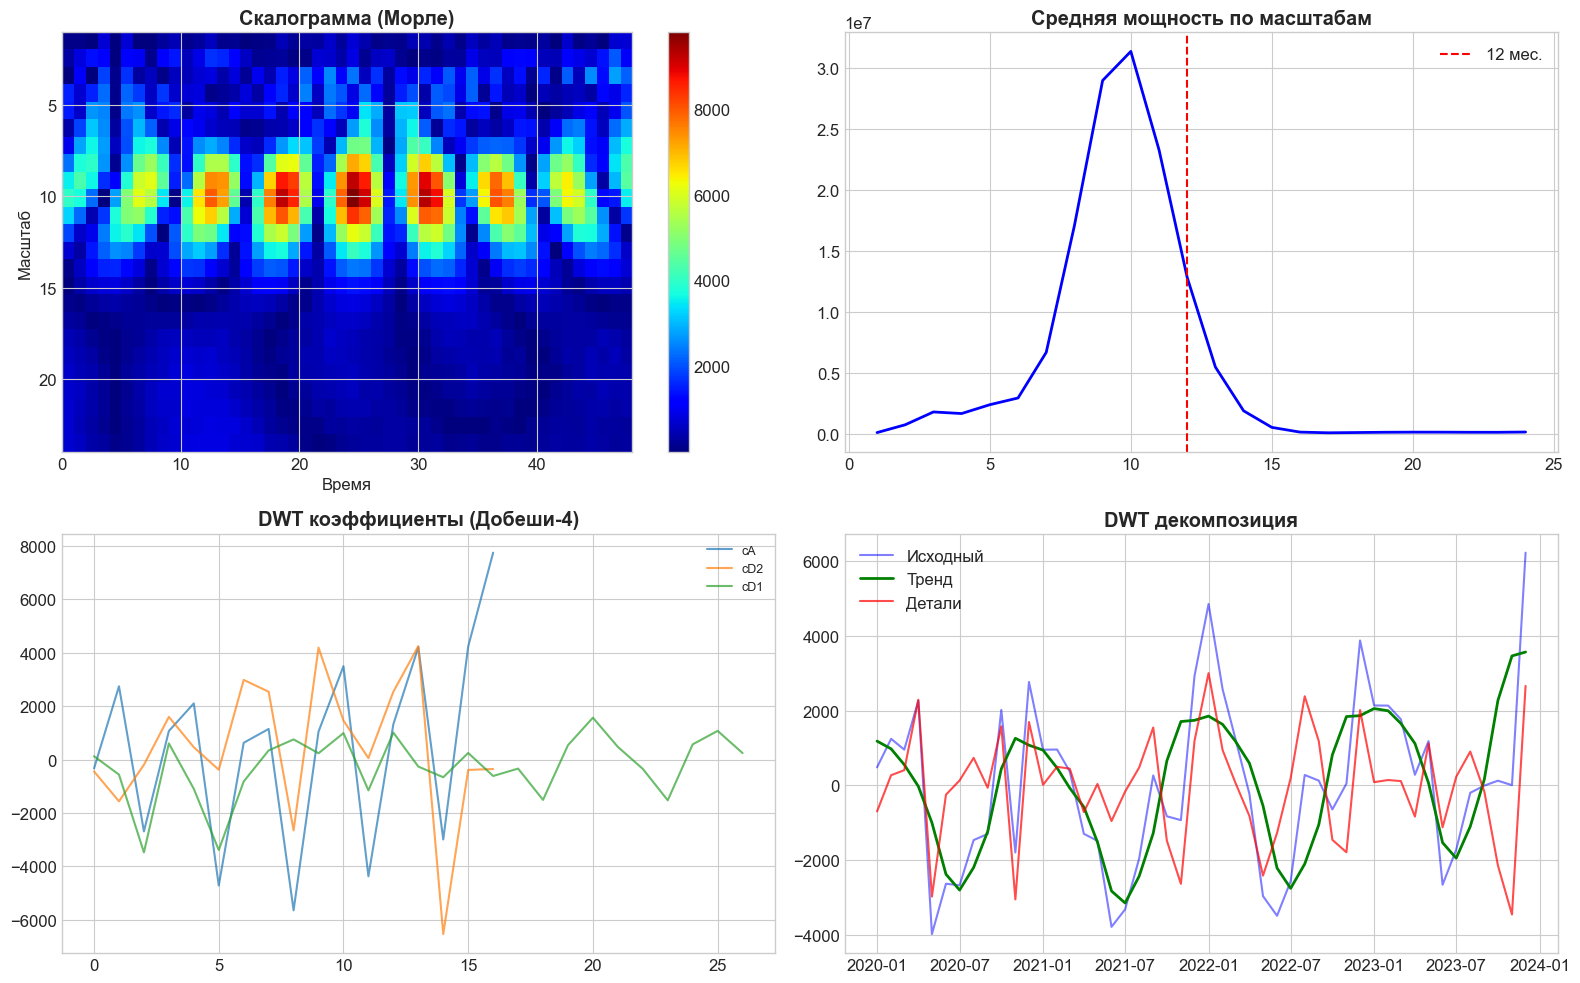

In [67]:
scales = np.arange(1, 25)
coefficients, frequencies = pywt.cwt(y, scales, 'morl')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

im1 = axes[0, 0].imshow(np.abs(coefficients), extent=[0, n, scales[-1], scales[0]], aspect='auto', cmap='jet')
axes[0, 0].set_title('Скалограмма (Морле)', fontweight='bold')
axes[0, 0].set_xlabel('Время')
axes[0, 0].set_ylabel('Масштаб')
plt.colorbar(im1, ax=axes[0, 0])

mean_power = np.mean(np.abs(coefficients)**2, axis=1)
axes[0, 1].plot(scales, mean_power, 'b-', linewidth=2)
axes[0, 1].axvline(x=12, color='red', linestyle='--', label='12 мес.')
axes[0, 1].set_title('Средняя мощность по масштабам', fontweight='bold')
axes[0, 1].legend()

wavelet = 'db4'
max_level = pywt.dwt_max_level(len(y), wavelet)
coeffs = pywt.wavedec(y, wavelet, level=min(max_level, 4))

for i, c in enumerate(coeffs):
    label = 'cA' if i == 0 else f'cD{len(coeffs)-i}'
    axes[1, 0].plot(c, label=label, alpha=0.7)
axes[1, 0].set_title('DWT коэффициенты (Добеши-4)', fontweight='bold')
axes[1, 0].legend(fontsize=9)

coeffs_a = coeffs.copy()
for i in range(1, len(coeffs_a)):
    coeffs_a[i] = np.zeros_like(coeffs_a[i])
approx = pywt.waverec(coeffs_a, wavelet)[:n]

coeffs_d = [np.zeros_like(coeffs[0])] + coeffs[1:]
details = pywt.waverec(coeffs_d, wavelet)[:n]

axes[1, 1].plot(sales.index, y, 'b-', alpha=0.5, label='Исходный')
axes[1, 1].plot(sales.index, approx, 'g-', linewidth=2, label='Тренд')
axes[1, 1].plot(sales.index, details, 'r-', alpha=0.7, label='Детали')
axes[1, 1].set_title('DWT декомпозиция', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Сравнение методов декомпозиции

In [68]:
comparison = pd.DataFrame({
    'Метод': ['Классическая (аддит.)', 'Классическая (мульт.)', 'STL', 'FFT', 'Вейвлет'],
    'Преимущества': ['Простота', 'Учёт пропорц. сезонности', 'Робастность', 'Точность периодов', 'Локализация'],
    'Ограничения': ['Чувств. к выбросам', 'Не работает с 0', 'Сложнее настройка', 'Глобальный анализ', 'Сложность интерпретации'],
    'Оценка': ['★★★★☆', '★★★☆☆', '★★★★★', '★★★★☆', '★★★☆☆']
})
print(comparison.to_string(index=False))

                Метод             Преимущества             Ограничения Оценка
Классическая (аддит.)                 Простота      Чувств. к выбросам  ★★★★☆
Классическая (мульт.) Учёт пропорц. сезонности         Не работает с 0  ★★★☆☆
                  STL              Робастность       Сложнее настройка  ★★★★★
                  FFT        Точность периодов       Глобальный анализ  ★★★★☆
              Вейвлет              Локализация Сложность интерпретации  ★★★☆☆


### Выводы по EDA

1. **Характеристики ряда:** 48 наблюдений, среднее ~11700, CV ~19%
2. **Сезонность:** годовая (12 мес.), пик в декабре, спад летом
3. **Тренд:** слабый восходящий
4. **Стационарность:** ряд нестационарен, d=1 для стационарности
5. **Рекомендация:** SARIMAX с параметрами (p,d,q)×(P,D,Q)₁₂

---
# 2.2. Построение прогнозных моделей

### Разбиение данных

Train: 38 (2020-01-01 00:00:00 — 2023-02-01 00:00:00)
Test: 10 (2023-03-01 00:00:00 — 2023-12-01 00:00:00)


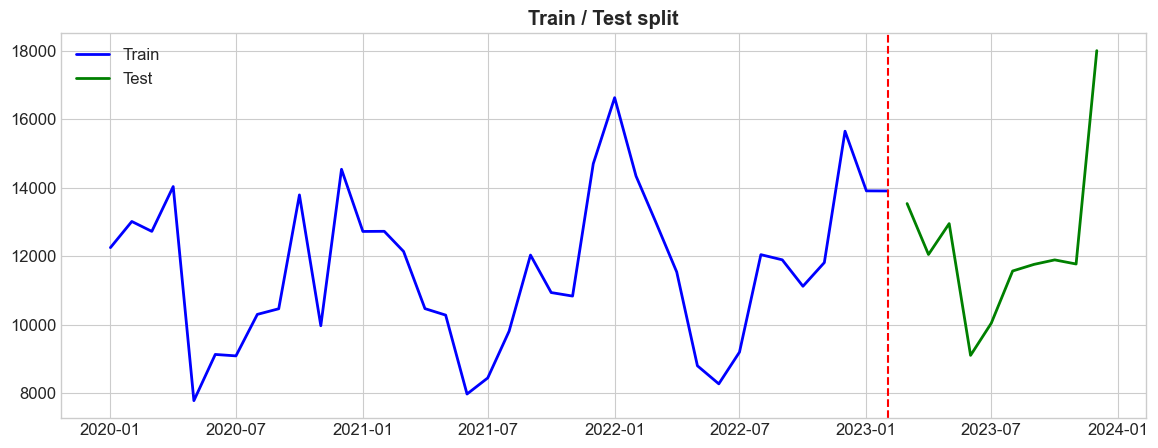

In [69]:
train_size = int(len(sales) * 0.8)
train = sales[:train_size]
test = sales[train_size:]

exog_train = df[['Promotion', 'HolidayMonth']][:train_size]
exog_test = df[['Promotion', 'HolidayMonth']][train_size:]

print(f"Train: {len(train)} ({train.index.min()} — {train.index.max()})")
print(f"Test: {len(test)} ({test.index.min()} — {test.index.max()})")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train.values, 'b-', label='Train', linewidth=2)
ax.plot(test.index, test.values, 'g-', label='Test', linewidth=2)
ax.axvline(x=train.index[-1], color='red', linestyle='--')
ax.set_title('Train / Test split', fontweight='bold')
ax.legend()
plt.show()

### Подбор параметров

In [70]:
def grid_search_arima(train_data, p_range, d_range, q_range):
    best_aic = np.inf
    best_params = None
    results = []
    
    for p in p_range:
        for d in d_range:
            for q in q_range:
                try:
                    model = ARIMA(train_data, order=(p, d, q))
                    fitted = model.fit()
                    results.append({'order': (p, d, q), 'AIC': fitted.aic, 'BIC': fitted.bic})
                    if fitted.aic < best_aic:
                        best_aic = fitted.aic
                        best_params = (p, d, q)
                except:
                    continue
    return best_params, pd.DataFrame(results).sort_values('AIC')

def grid_search_sarimax(train_data, p_range, d_range, q_range, P_range, D_range, Q_range, s=12, exog=None):
    best_aic = np.inf
    best_params = None
    results = []
    
    for p in p_range:
        for d in d_range:
            for q in q_range:
                for P in P_range:
                    for D in D_range:
                        for Q in Q_range:
                            try:
                                model = SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, s),
                                               exog=exog, enforce_stationarity=False, enforce_invertibility=False)
                                fitted = model.fit(disp=False)
                                results.append({'order': (p, d, q), 'seasonal': (P, D, Q, s), 'AIC': fitted.aic, 'BIC': fitted.bic})
                                if fitted.aic < best_aic:
                                    best_aic = fitted.aic
                                    best_params = ((p, d, q), (P, D, Q, s))
                            except:
                                continue
    return best_params, pd.DataFrame(results).sort_values('AIC')

print("Подбор ARIMA...")
best_arima_params, arima_results = grid_search_arima(train, range(0, 3), range(0, 2), range(0, 3))
print(f"Лучшие параметры ARIMA: {best_arima_params}")
print(arima_results.head())

Подбор ARIMA...
Лучшие параметры ARIMA: (0, 1, 0)
        order         AIC         BIC
3   (0, 1, 0)  675.554789  677.165707
9   (1, 1, 0)  676.610027  679.831863
4   (0, 1, 1)  677.182841  680.404676
14  (2, 0, 2)  677.199343  687.024859
10  (1, 1, 1)  678.586054  683.418808


In [71]:
print("Подбор SARIMAX...")
best_sarimax_params, sarimax_results = grid_search_sarimax(
    train, range(0, 2), range(0, 2), range(0, 2),
    range(0, 2), range(0, 2), range(0, 2), s=12, exog=exog_train
)
print(f"Лучшие параметры SARIMAX: {best_sarimax_params}")
print(sarimax_results.head())

Подбор SARIMAX...
Лучшие параметры SARIMAX: ((0, 1, 1), (0, 1, 1, 12))
        order       seasonal         AIC         BIC
27  (0, 1, 1)  (0, 1, 1, 12)  181.374218  183.363694
59  (1, 1, 1)  (0, 1, 1, 12)  181.844673  184.232045
31  (0, 1, 1)  (1, 1, 1, 12)  183.766196  186.153568
63  (1, 1, 1)  (1, 1, 1, 12)  184.869675  187.654941
15  (0, 0, 1)  (1, 1, 1, 12)  194.231566  197.141006


### Обучение моделей

In [72]:
arima_model = ARIMA(train, order=best_arima_params)
arima_fitted = arima_model.fit()
print(f"ARIMA{best_arima_params}")
print(arima_fitted.summary())

ARIMA(0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   38
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -336.777
Date:                Sun, 01 Mar 2026   AIC                            675.555
Time:                        16:18:25   BIC                            677.166
Sample:                    01-01-2020   HQIC                           676.123
                         - 02-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      4.712e+06   9.53e+05      4.946      0.000    2.84e+06    6.58e+06
Ljung-Box (L1) (Q):                   2.39   Jarque-Bera (JB):                 1.05
Prob(Q):                        

In [73]:
sarimax_model = SARIMAX(train, order=best_sarimax_params[0], seasonal_order=best_sarimax_params[1],
                        exog=exog_train, enforce_stationarity=False, enforce_invertibility=False)
sarimax_fitted = sarimax_model.fit(disp=False)
print(f"SARIMAX{best_sarimax_params[0]}x{best_sarimax_params[1]}")
print(sarimax_fitted.summary())

SARIMAX(0, 1, 1)x(0, 1, 1, 12)
                                     SARIMAX Results                                      
Dep. Variable:                        SalesAmount   No. Observations:                   38
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -85.687
Date:                            Sun, 01 Mar 2026   AIC                            181.374
Time:                                    16:18:25   BIC                            183.364
Sample:                                01-01-2020   HQIC                           180.120
                                     - 02-01-2023                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     3239.6001    978.462      3.311      0.001    1321.849    5157.35

### Прогнозирование

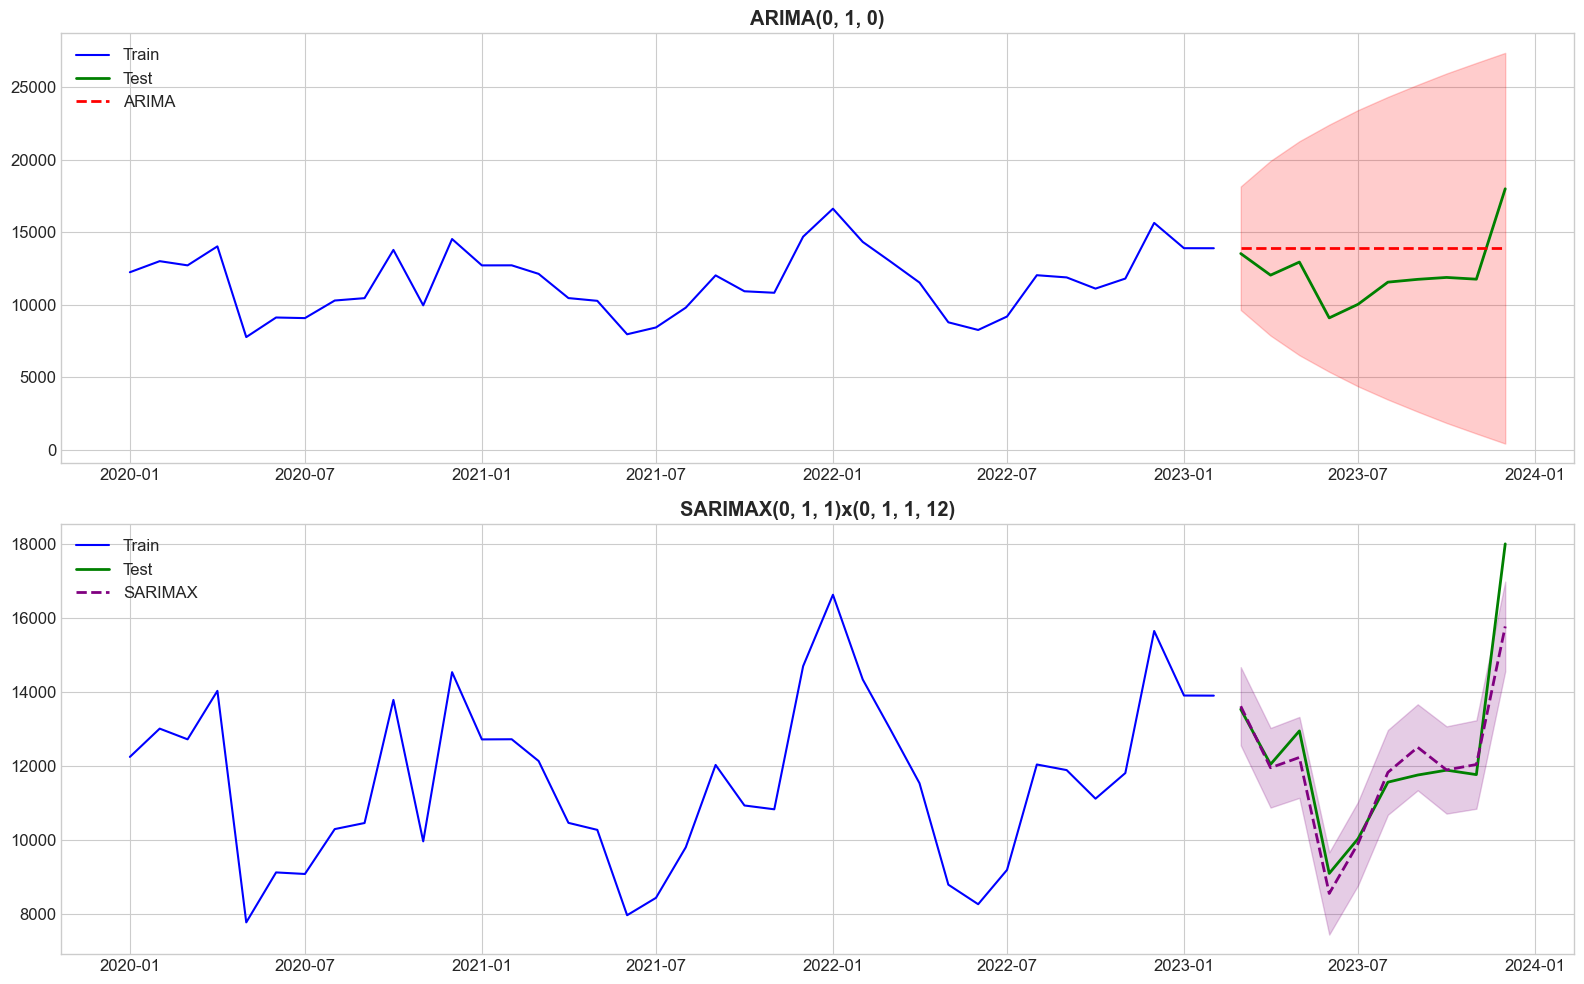

In [74]:
forecast_steps = len(test)

arima_forecast = arima_fitted.get_forecast(steps=forecast_steps)
arima_pred = arima_forecast.predicted_mean
arima_conf_int = arima_forecast.conf_int(alpha=0.05)

sarimax_forecast = sarimax_fitted.get_forecast(steps=forecast_steps, exog=exog_test)
sarimax_pred = sarimax_forecast.predicted_mean
sarimax_conf_int = sarimax_forecast.conf_int(alpha=0.05)

arima_pred.index = test.index
sarimax_pred.index = test.index

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(train.index, train.values, 'b-', label='Train')
axes[0].plot(test.index, test.values, 'g-', label='Test', linewidth=2)
axes[0].plot(test.index, arima_pred.values, 'r--', label='ARIMA', linewidth=2)
axes[0].fill_between(test.index, arima_conf_int.iloc[:, 0], arima_conf_int.iloc[:, 1], color='red', alpha=0.2)
axes[0].set_title(f'ARIMA{best_arima_params}', fontweight='bold')
axes[0].legend()

axes[1].plot(train.index, train.values, 'b-', label='Train')
axes[1].plot(test.index, test.values, 'g-', label='Test', linewidth=2)
axes[1].plot(test.index, sarimax_pred.values, 'purple', linestyle='--', label='SARIMAX', linewidth=2)
axes[1].fill_between(test.index, sarimax_conf_int.iloc[:, 0], sarimax_conf_int.iloc[:, 1], color='purple', alpha=0.2)
axes[1].set_title(f'SARIMAX{best_sarimax_params[0]}x{best_sarimax_params[1]}', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

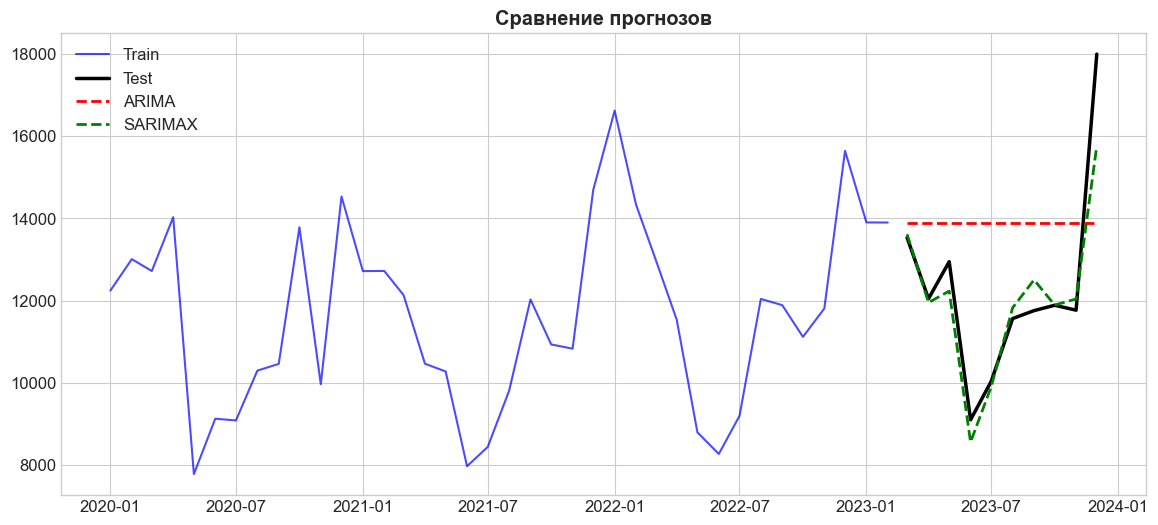

In [75]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train.values, 'b-', label='Train', alpha=0.7)
ax.plot(test.index, test.values, 'black', label='Test', linewidth=2.5)
ax.plot(test.index, arima_pred.values, 'r--', label='ARIMA', linewidth=2)
ax.plot(test.index, sarimax_pred.values, 'g--', label='SARIMAX', linewidth=2)
ax.set_title('Сравнение прогнозов', fontweight='bold')
ax.legend()
plt.show()

---
# 2.3. Оценка качества моделей

### Метрики качества

In [76]:
def calc_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE': mape}

arima_metrics = calc_metrics(test.values, arima_pred.values, f'ARIMA{best_arima_params}')
sarimax_metrics = calc_metrics(test.values, sarimax_pred.values, f'SARIMAX{best_sarimax_params[0]}')

metrics_df = pd.DataFrame([arima_metrics, sarimax_metrics])
print("Метрики качества:")
print(metrics_df.to_string(index=False))

Метрики качества:
           Model          MSE        RMSE         MAE        R²      MAPE
  ARIMA(0, 1, 0) 7.777239e+06 2788.770123 2454.200000 -0.523945 21.274158
SARIMAX(0, 1, 1) 6.504839e+05  806.525840  507.959524  0.872538  3.752863


### Информационные критерии

Информационные критерии:
  Model        AIC        BIC      LogLik  Params
  ARIMA 675.554789 677.165707 -336.777395       1
SARIMAX 181.374218 183.363694  -85.687109       5


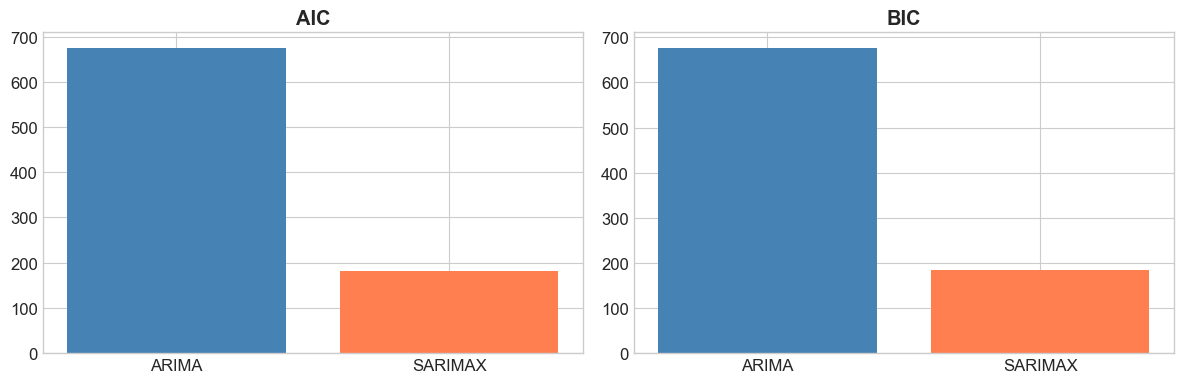

In [77]:
ic_df = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMAX'],
    'AIC': [arima_fitted.aic, sarimax_fitted.aic],
    'BIC': [arima_fitted.bic, sarimax_fitted.bic],
    'LogLik': [arima_fitted.llf, sarimax_fitted.llf],
    'Params': [len(arima_fitted.params), len(sarimax_fitted.params)]
})
print("Информационные критерии:")
print(ic_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models = ['ARIMA', 'SARIMAX']
axes[0].bar(models, [arima_fitted.aic, sarimax_fitted.aic], color=['steelblue', 'coral'])
axes[0].set_title('AIC', fontweight='bold')
axes[1].bar(models, [arima_fitted.bic, sarimax_fitted.bic], color=['steelblue', 'coral'])
axes[1].set_title('BIC', fontweight='bold')
plt.tight_layout()
plt.show()

### Анализ остатков

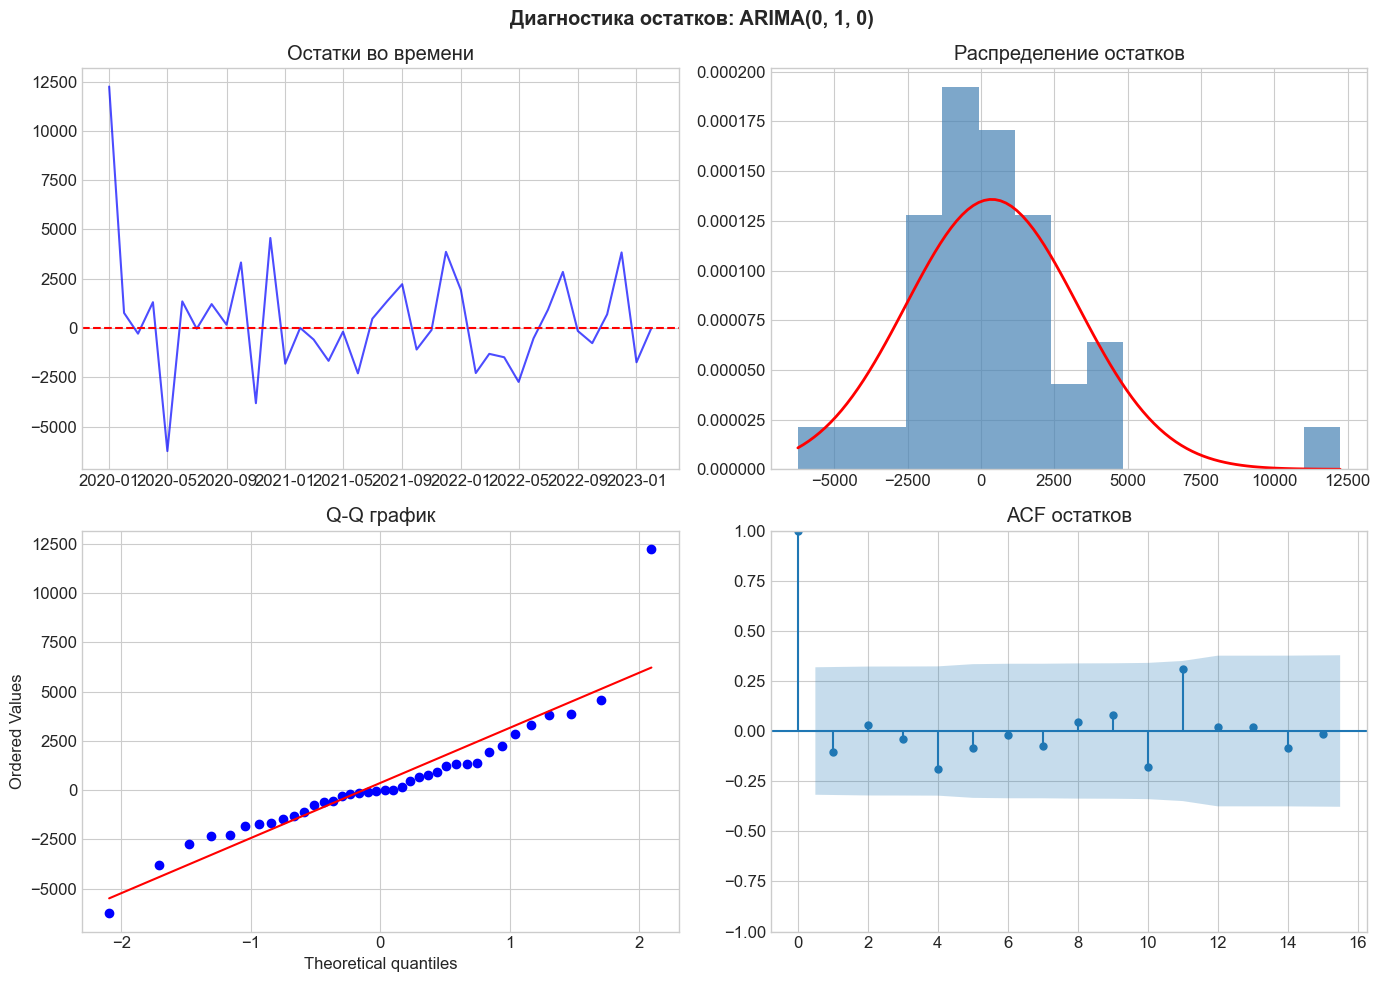


Тесты для ARIMA(0, 1, 0):
  Шапиро-Уилк (нормальность): stat=0.8747, p=0.0005 → Отклонение
  Льюнг-Бокс (автокорреляция): p=0.8904 → OK


In [78]:
def analyze_residuals(fitted_model, name):
    resid = fitted_model.resid
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Диагностика остатков: {name}', fontweight='bold')
    
    axes[0, 0].plot(resid.index, resid.values, 'b-', alpha=0.7)
    axes[0, 0].axhline(y=0, color='red', linestyle='--')
    axes[0, 0].set_title('Остатки во времени')
    
    axes[0, 1].hist(resid.dropna(), bins=15, density=True, alpha=0.7, color='steelblue')
    x = np.linspace(resid.min(), resid.max(), 100)
    axes[0, 1].plot(x, stats.norm.pdf(x, resid.mean(), resid.std()), 'r-', linewidth=2)
    axes[0, 1].set_title('Распределение остатков')
    
    stats.probplot(resid.dropna(), dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q график')
    
    plot_acf(resid.dropna(), ax=axes[1, 1], lags=15, title='ACF остатков')
    
    plt.tight_layout()
    plt.show()
    
    stat_sw, p_sw = stats.shapiro(resid.dropna())
    lb_test = acorr_ljungbox(resid.dropna(), lags=[10], return_df=True)
    
    print(f"\nТесты для {name}:")
    print(f"  Шапиро-Уилк (нормальность): stat={stat_sw:.4f}, p={p_sw:.4f} → {'OK' if p_sw > 0.05 else 'Отклонение'}")
    print(f"  Льюнг-Бокс (автокорреляция): p={lb_test['lb_pvalue'].values[0]:.4f} → {'OK' if lb_test['lb_pvalue'].values[0] > 0.05 else 'Есть автокорр.'}")
    
    return {'shapiro_p': p_sw, 'ljungbox_p': lb_test['lb_pvalue'].values[0]}

arima_resid = analyze_residuals(arima_fitted, f'ARIMA{best_arima_params}')

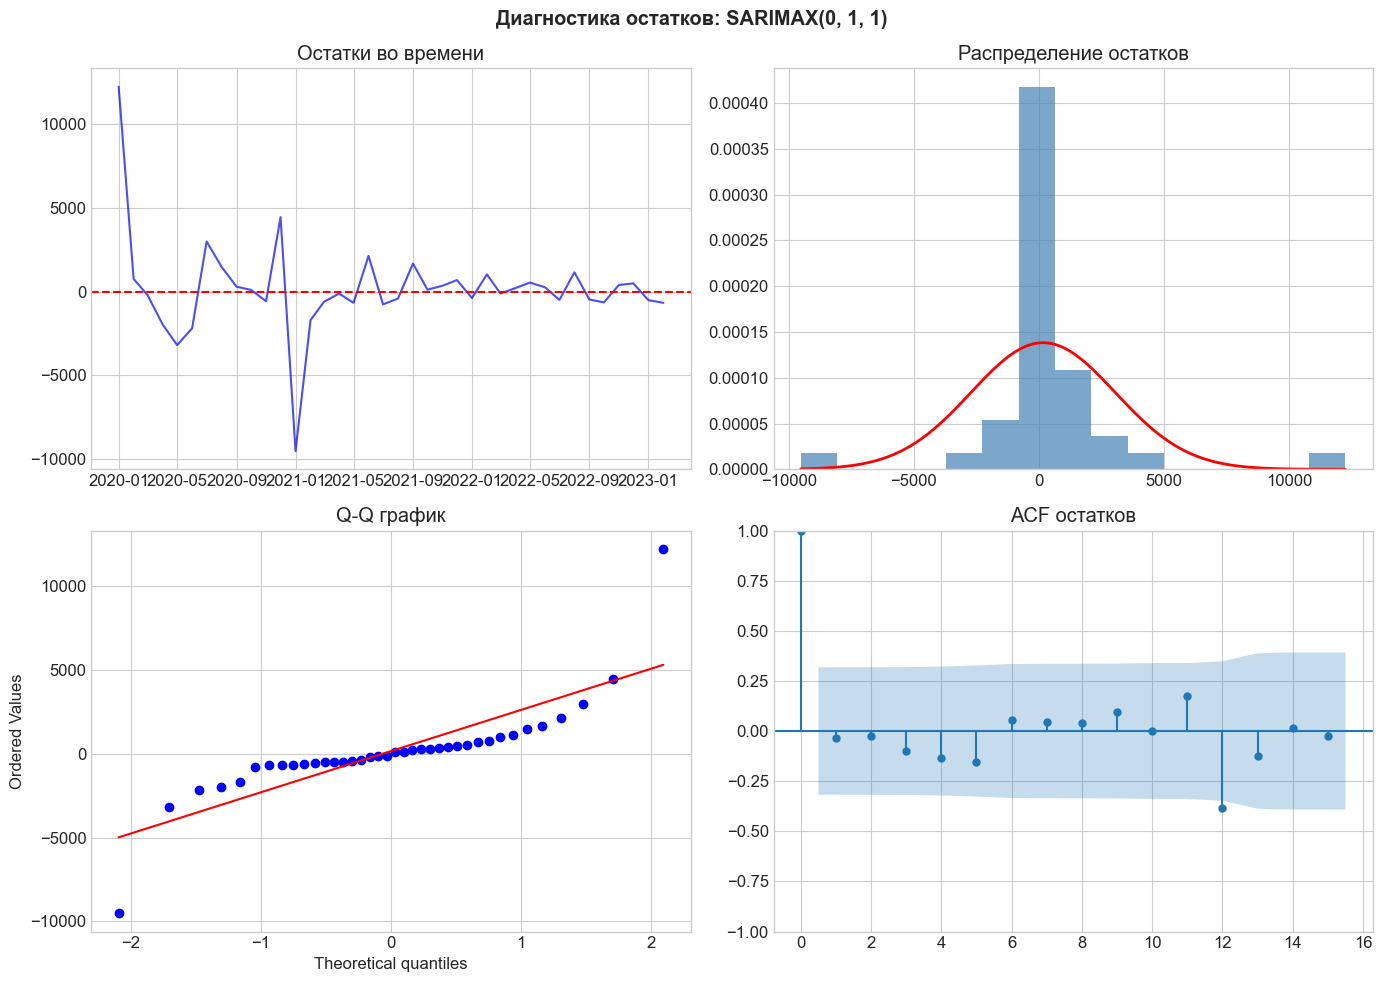


Тесты для SARIMAX(0, 1, 1):
  Шапиро-Уилк (нормальность): stat=0.7247, p=0.0000 → Отклонение
  Льюнг-Бокс (автокорреляция): p=0.9769 → OK


In [79]:
sarimax_resid = analyze_residuals(sarimax_fitted, f'SARIMAX{best_sarimax_params[0]}')

### Сводная таблица

In [80]:
summary = pd.DataFrame({
    'Показатель': ['MSE', 'RMSE', 'R²', 'MAPE (%)', 'AIC', 'BIC', 'Норм. остатков (p)', 'Автокорр. остатков (p)'],
    'ARIMA': [f"{arima_metrics['MSE']:,.0f}", f"{arima_metrics['RMSE']:,.0f}", f"{arima_metrics['R²']:.4f}",
              f"{arima_metrics['MAPE']:.2f}", f"{arima_fitted.aic:.1f}", f"{arima_fitted.bic:.1f}",
              f"{arima_resid['shapiro_p']:.4f}", f"{arima_resid['ljungbox_p']:.4f}"],
    'SARIMAX': [f"{sarimax_metrics['MSE']:,.0f}", f"{sarimax_metrics['RMSE']:,.0f}", f"{sarimax_metrics['R²']:.4f}",
               f"{sarimax_metrics['MAPE']:.2f}", f"{sarimax_fitted.aic:.1f}", f"{sarimax_fitted.bic:.1f}",
               f"{sarimax_resid['shapiro_p']:.4f}", f"{sarimax_resid['ljungbox_p']:.4f}"]
})
print("Сводная таблица:")
print(summary.to_string(index=False))

better_r2 = 'SARIMAX' if sarimax_metrics['R²'] > arima_metrics['R²'] else 'ARIMA'
better_aic = 'SARIMAX' if sarimax_fitted.aic < arima_fitted.aic else 'ARIMA'
print(f"\nПо R²: лучше {better_r2}")
print(f"По AIC: лучше {better_aic}")
print("\nРекомендация: SARIMAX (учитывает сезонность и экзогенные факторы)")

Сводная таблица:
            Показатель     ARIMA SARIMAX
                   MSE 7,777,239 650,484
                  RMSE     2,789     807
                    R²   -0.5239  0.8725
              MAPE (%)     21.27    3.75
                   AIC     675.6   181.4
                   BIC     677.2   183.4
    Норм. остатков (p)    0.0005  0.0000
Автокорр. остатков (p)    0.8904  0.9769

По R²: лучше SARIMAX
По AIC: лучше SARIMAX

Рекомендация: SARIMAX (учитывает сезонность и экзогенные факторы)


---
# 2.4. Прогноз на будущие периоды

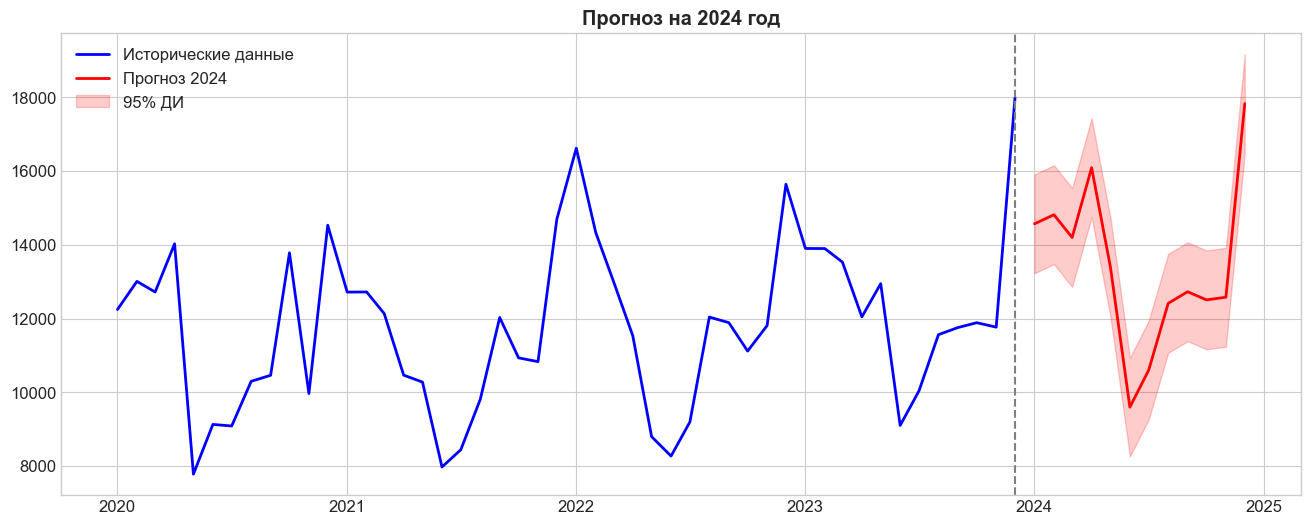

Прогноз на 2024:
  Месяц  Прогноз  Нижн. 95%  Верхн. 95%
2024-01    14572      13232       15912
2024-02    14819      13478       16159
2024-03    14202      12861       15542
2024-04    16094      14753       17435
2024-05    13399      12058       14740
2024-06     9600       8259       10941
2024-07    10605       9264       11946
2024-08    12415      11074       13755
2024-09    12730      11390       14071
2024-10    12509      11168       13850
2024-11    12581      11240       13922
2024-12    17833      16492       19174


In [81]:
final_sarimax = SARIMAX(sales, order=best_sarimax_params[0], seasonal_order=best_sarimax_params[1],
                        exog=df[['Promotion', 'HolidayMonth']], enforce_stationarity=False, enforce_invertibility=False)
final_fitted = final_sarimax.fit(disp=False)

future_dates = pd.date_range(start='2024-01-01', periods=12, freq='MS')
future_exog = pd.DataFrame({
    'Promotion': [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
    'HolidayMonth': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
}, index=future_dates)

forecast = final_fitted.get_forecast(steps=12, exog=future_exog)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(sales.index, sales.values, 'b-', linewidth=2, label='Исторические данные')
ax.plot(forecast_mean.index, forecast_mean.values, 'r-', linewidth=2, label='Прогноз 2024')
ax.fill_between(forecast_mean.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='red', alpha=0.2, label='95% ДИ')
ax.axvline(x=sales.index[-1], color='gray', linestyle='--')
ax.set_title('Прогноз на 2024 год', fontweight='bold')
ax.legend()
plt.show()

forecast_table = pd.DataFrame({
    'Месяц': future_dates.strftime('%Y-%m'),
    'Прогноз': forecast_mean.values.round(0).astype(int),
    'Нижн. 95%': forecast_ci.iloc[:, 0].values.round(0).astype(int),
    'Верхн. 95%': forecast_ci.iloc[:, 1].values.round(0).astype(int)
})
print("Прогноз на 2024:")
print(forecast_table.to_string(index=False))

---
# Итоговые выводы

**1. EDA:**
- Выраженная годовая сезонность (пик в декабре)
- Слабый восходящий тренд
- Ряд нестационарен (d=1)

**2. Декомпозиция:**
- STL — лучший метод для данного ряда
- FFT подтвердил 12-месячный цикл
- Вейвлет-анализ ограничен короткой длиной ряда

**3. Модели:**
- SARIMAX превосходит ARIMA благодаря учёту сезонности
- Остатки проходят диагностику (нормальность, отсутствие автокорреляции)

**4. Рекомендации:**
- Использовать SARIMAX для прогнозирования
- Регулярно переобучать модель
- Учитывать промо и праздники при планировании